# Computing general observables
---

<font size="5"><b>Goal:</b>
Become acquainted with how to compute general observables with SAFIRE.
</font>

&nbsp;

## What you will learn
---

<font size="4">

1. What an "estimator" is and how to set one up in the json input file
2. What a mixed estimator is and when to use one to compute an observable
3. What a back-propagated estimator is and when to use one to compute an observable
4. How to compute observables in post-processing with afqmctools
</font>

&nbsp;

## Introduction
---

<font size="4">
SAFIRE uses "estimators" to compute observables.
Each estimator corresponds to a formal method for computing an observable - i.e. mixed estimators, back-propagated estimators, etc. - We will explain each of the these in the next section.
As we mentioned in the
</font>

[<font size="4">understanding the Input file tutorial</font>](https://colab.research.google.com/drive/1rWeqD-DVQNMN8ILqelEZ56OURmCYpozp),

<font size="4">
you can add estimators to an AFQMC calculation using an "estimator" input block.
By default, an "energy" estimator is included which is a specialized mixed estimator.
Other estimators allow you to specify one or more additional observables to compute.
</font>

&nbsp;

## Formal Background
---

Although we have not seen this explicitly, we have, so far, computed the ground state energy with AFQMC using a so-called
mixed estimator of the form

$$
\langle \hat{O} \rangle_{Mixed} = \frac{1}{\sum_k W_{n,k}} \sum_k W_{n,k} \frac{\langle \Psi_T | \hat{O} | \Phi_{n,k} \rangle }{\langle \Psi_T | \Phi_{n,k} \rangle}
$$

where $n$ is the projection step index,
$| \Phi_{n,k} \rangle$ are Slater determinant random walkers with weight $W_{n,k}$ (from importance sampling),
and $| \Psi_T \rangle$ is the trial wavefunction.
The mixed estimator provides an unbiased estimate for any observable which commutes with the Hamiltonian.
For the AFQMC energy, $\hat{O} = \hat{H}$, and trivially $[ \hat{O}, \hat{H} ] = 0$;
therefore, the mixed estimator is an unbiased choice for the total ground state energy.

On the other hand, it is often interesting to compute observables which do not commute with the Hamiltonian.
For example, the one-body reduced density matrix, from which many properties can be computed, does not commute
with the Hamiltonian.
In these cases, a back-propagated estimator is necessary to mitigate the bias that would be incurred
by using a mixed-estimator.
The back-propagated estimator has the form,
$$
\langle \hat{O} \rangle_{BP} = \frac{1}{\sum_k W_{n+m,k}} \sum_k W_{n+m,k} \frac{\langle \tilde{\Phi}_{m,k} | \hat{O} | \Phi_{n,k} \rangle }{\langle \tilde{\Phi}_{m,k} |\Phi_{n,k}\rangle}
$$

where $| \Phi_{n,k} \rangle$ are the usual forward-projected Slater determinant random walkers,
and $| \tilde{\Phi}_{m,k} \rangle$ are the back-propgated walkers given by,
$$
| \tilde{\Phi}_{m,k} \rangle = \hat{B}^\dagger( (x - \bar{x})_{n,k} ) ... \hat{B}^\dagger( (x - \bar{x})_{n+m-1,k} ) | \Psi_T \rangle
$$.
The index $n$ corresponds to the current forward projection step,
and $m$ is the back-propagated step index.
We note that each random walker has a corresponding back-propagated partner
which share the same path in auxiliary-field space.
It is important to note that the two Slater determinants are
distinct from each other since the propagator $B(x - \bar{x})$ is applied differently to each.
i.e. the propagator is applied to different Slater determinants when moving in the forward-, and backward-directions.


## ▶️ Run the cell below to setup the tutorial
----------------------------------------------

In [ ]:
%load_ext autoreload
# Run me (shift+enter or click the play button) to setup the tutorial!
from pathlib import Path

# simple setup
from tutorial_utils import run_afqmc, get_scratch_dir

#TODO: update this to a good directory for scratch files
home = Path.home() / ".scratch"
scratch_dir = get_scratch_dir("04_observables_solids", home)

# copy files to scratch
import shutil
_ = shutil.copy("files/hamil.h5", scratch_dir)
_ = shutil.copy("files/wfn.h5", scratch_dir)

In [ ]:
!ls  -al {scratch_dir}

total 28938
drwxrwxr-x  2 beskridge beskridge     4096 Dec  1 17:03 .
drwxrwxr-x 21 beskridge beskridge     4096 Dec  1 16:58 ..
-rw-rw-r--  1 beskridge beskridge      723 Dec  1 17:03 afqmc_1.json
-rw-rw-r--  1 beskridge beskridge      659 Dec  1 16:59 afqmc.json
-rw-rw-r--  1 beskridge beskridge   888700 Dec  2 07:46 hamil.h5
-rw-rw-r--  1 beskridge beskridge   224023 Dec  1 17:02 qmc.s000.scalar.dat
-rw-rw-r--  1 beskridge beskridge   165274 Dec  1 17:07 qmc.s001.scalar.dat
-rw-rw-r--  1 beskridge beskridge 28285584 Dec  1 17:07 qmc.s001.stat.h5
-rw-rw-r--  1 beskridge beskridge    48768 Dec  2 07:46 wfn.h5


&nbsp;

## Setup the Test System
---

We will again use Si in its primtive cell at equilibrium represent in a basis of Kohn-Sham bands as a toy case to run
concrete calculations on.

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/solids/Si_primitive.png" width="600">
</div>

The trial wavefunction is also derived from the DFT solution.
We have provided HDF5 files containing the Hamiltonian and trial wavefunctions, respectively.
The code block above should have copied them to your scratch directory.


&nbsp;

## The "Energy" Estimator
---

By default, SAFIRE will include an "energy estimator" in the calculation.
This is formally a mixed estimator where $\hat{O} = \hat{H}$.
The Hamiltonian trivially commutes with itself, so a mixed estimator of the energy is unbiased.

You can add an energy estimator input block to your json input file in order to customize its settings.
For example, in the input block,

```json
"estimator" : {
  "name" : "energy",
  "print_components" : True,        
  "overwrite" : True
}
```

the "name" keyword tells us what kind of estimator we want.
In this case, we want an "energy" estimator.
We are setting the "print_components" and "overwrite" flags to true.
"print_components" tells SAFIRE to print the one-body, two-body direct, and two-body exchange contributions to the energy separately.
"overwrite" tells SAFIRE to overwrite the default energy estimator
with the one that we have defined.

&nbsp;

### Most Common Settings
---

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        print_components</b></font> |  <font size="4">False</font> | <font size="4"> If True, print the one-body, two-body coulomb, and two-body exchange contributions to the energy in the `*.scalar.dat` file </font> |
| <font size="4"><b> equil_multiplier </b></font> | <font size="4">0</font> |  <font size="4">The multiplier that determines the length of the equilibration phase. The equilibration phase length is computed as $(equilibration\_length) = (equil\_multiplier) * (population\_control\_inveral)$ where the population control interval is defined in the execute block. During the equilibration phase, observables are not computed. </font>|
| <font size="4"><b>        overwrite</b></font> | <font size="4">False</font> |  <font size="4"> If True, overwrite the default energy estimator with the explicitly defined energy estimator </font>|

&nbsp;

### Less Common Settings

---

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        print_sign</b></font> | <font size="4">False</font> | <font size="4"> If True, print verious quantities related to the sign/phase of random walkers in the `*.scalar.dat` file </font> |
| <font size="4"><b>        remove</b></font> |  <font size="4">False</font> |  <font size="4"> If True, remove the default energy estimator. **Note that the explicitly defined energy estimator will not be used in the calculation!** </font>|
| <font size="4"><b>        truncate</b></font> |  <font size="4">False</font> |  <font size="4"> If True, truncate the energy such that data that fall outisde of the range $[-3 var, 3 var]$, with $var$ being the variance, are set to either $-3 var$ or $3 var$, whichever is closer </font>|

&nbsp;


In [ ]:
from afqmctools.inputs.from_hdf import write_json

# some shared parameters for the AFQMC run
execute_options = {
    "walker_set" : {
        "walker_type" : "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "population_control_interval" : 10,
    "measure_interval_multiplier": 1,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 200,
    "seed" : 42,
    "estimator" : {
        "name" : "energy",
        "print_components" : True,
        "overwrite" : True
    }
}

write_json(
    scratch_dir / "afqmc.json",
    fwfn0=scratch_dir / "wfn.h5",
    fham0=scratch_dir / "hamil.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options
)

### ▶️ Your Turn: Run SAFIRE with an explicit energy estimator block
---------------------------------------------------------------------

Now you can run AFQMC, and you should see the following column headers in the `*scalar.dat` file.

```log
 block  time  nWalkers weight PseudoEloc LogOvlpFactor EnergyEstim__nume_real  EnergyEstim__nume_imag EnergyEstim__deno_real  EnergyEstim__deno_imag EnergyEstim__timer OneBodyEnergyEstim__nume_real EXXEnergyEstim__nume_real ECoulEnergyEstim__nume_real MixedEstim_timer Eshift freeMemory
```

In [ ]:
run_afqmc(
    run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there as well
    input_file="afqmc.json",
    np=16,                              # number of MPI tasks
    output_file=None
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 9c503defb1cb7612b100318b4394dce7c4b1fda1
app git commit date: Mon Dec 1 11:33:42 2025 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series      

168.0093734851107

You can check the `*.scalar.dat` file to verify that the extra columns that we requested were printed.

In [ ]:
!head -n 10 $scratch_dir/qmc.s000.scalar.dat

# block  time  nWalkers weight PseudoEloc LogOvlpFactor EnergyEstim__nume_real  EnergyEstim__nume_imag EnergyEstim__deno_real  EnergyEstim__deno_imag EnergyEstim__timer OneBodyEnergyEstim__nume_real EXXEnergyEstim__nume_real ECoulEnergyEstim__nume_real Eshift freeMemory 
1 0.1 3200 3193.83 3.881407059893014 -0.09377335811385526 -0.6175906877388309 -3.331074588113164e-05 1 -1.891787592895149e-18 0.012213477 -0.766223449445778 -0.7486063763212425 0.8972391380281896 3.89341397529  173251 
2 0.2 3200 3200.03 3.866974486201767 -0.1583283046490253 -0.6268622839668104 -0.0002250837228744497 1 -1.771516690823898e-19 0.012388142 -0.7652713607292679 -0.7401160070166051 0.8785250837790629 3.86986168216  173248 
3 0.3 3200 3199.98 3.864644961122231 -0.2143974434160945 -0.6348695462029226 -0.000118495987401995 1 1.077133313868305e-18 0.01222627 -0.7642975681342841 -0.7326560394950815 0.8620840614264429 3.86442663272  173247 
4 0.4 3200 3199.97 3.853594851663948 -0.263600939567165 -0.642245907878716

&nbsp;

## Extracting and Analyzing the AFQMC energy.
---

We learned about basic energy analysis using the CLI and the `analyze_scalar_data()` Python function in the [Hello SAFIRE](https://colab.research.google.com/drive/1zfdEh-c1mClzhXGOVdzANNzyhG1gBMBG) tutorial.
We can use the same tools here to get the average AFQMC energy and the stochastic uncertainty.

For pedagogical reasons, we will instead read the entire scalar data file so that we can plot several of the data columns as a function of total projection time.
In the code block below, the total energy (solid blue line) is plotted along with the sum of the three individual columns (dotted orange line) corresponding to the one-body energy, the direct / Coulomb interaction energy, and the exchange energy.
The two curves agree with each other to machine precision.

Run the code block below.

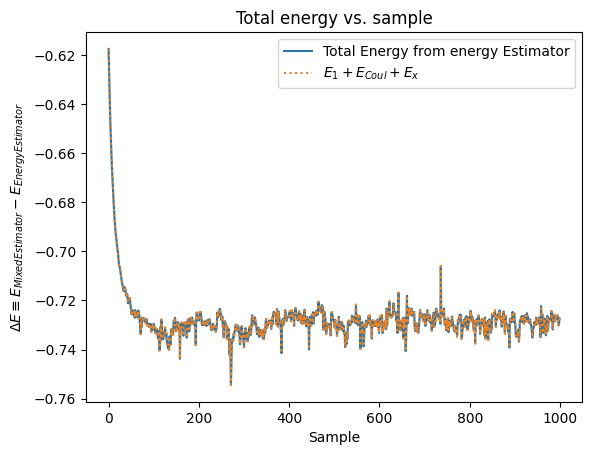

In [ ]:
from types import SimpleNamespace
import matplotlib.pyplot as plt

from stats.scalar_dat import analyze_scalar_data,read_scalar_table

# read scalar table and return as a pandas DataFrame
args = SimpleNamespace(
    fname=scratch_dir / "qmc.s000.scalar.dat",
    append=None,
    mark_header="#"
)
df = read_scalar_table(args)


# read the energy components
one_body_energy = df["OneBodyEnergyEstim__nume_real"].values
direct_coulomb_energy = df["ECoulEnergyEstim__nume_real"].values
exchange_energy = df["EXXEnergyEstim__nume_real"].values

two_body_energy = direct_coulomb_energy + exchange_energy

# read the total energy
total_energy = df["EnergyEstim__nume_real"].values

# plot the energy both ways

plt.plot(total_energy,label="Total Energy from energy Estimator")
plt.plot(one_body_energy + direct_coulomb_energy + exchange_energy, ":", label=r"$E_1 + E_{Coul} + E_{x}$")

plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"Total energy vs. sample")

plt.show()

&nbsp;

## Computing Observables using a "Mixed" Estimator
---

SAFIRE also includes a mixed estimator that periodically evaluates,

$$
\langle \hat{O} ⟩_{Mixed} = \frac{1}{\sum_k W_{n,k}} \sum_k W_{n,k} \frac{\langle \Psi_T | \hat{O} | \Phi_{n,k} \rangle }{\langle \Psi_T | \Phi_{n,k} \rangle},
$$
where $\hat{O}$ is an operator.
The one-body reduced density matrix (1rdm), given by

$$\hat{O} = \hat{\rho}^1 = \sum_{ij}\sum_{\sigma \sigma'} \hat{c}^\dagger_{i \sigma}\hat{c}_{j \sigma'},$$

and the two-body reduced density matrix (2rdm), given by,

$$\hat{O} = \hat{\rho}^2 = \sum_{ijkl}\sum_{\sigma \sigma'}\hat{c}^\dagger_{i\sigma}\hat{c}^\dagger_{j\sigma'}\hat{c}_{k\sigma'}\hat{c}_{l\sigma}$$

are common observables.

<div class="alert alert-block alert-info">
<b>Note:</b>
    computing the 2rdm is very time and memory intensive; this should only be done for small systems.
</div>

### Specifying Observables to Measure
---------------------------------------

You can specify which observables you want to compute by
adding a corresponding observable block to an estimator
block.
For example, the estimator block below includes both the 1rdm, and the diagonal 2rdm.

```json
"estimator" : {
    "name" : "mixed",
    "onerdm" : {
        "name" : "my_onerdm"
    },
    "diag2rdm" : {
        "name" : "my_diag2rdm"
    }
}
```

As we will see later, this is exactly how observables are specified for the BP estimator as well.
See the [User Manual](https://users.flatironinstitute.org/~beskridge/safire/user_manual/observables.html#observables) for a complete list of currently implemented observables.

### Pedagogical Demonstration
-----------------------------

Below, we will use a mixed estimator to compute the 1-rdm, and the diagonal 2-rdm.
We can then directly compute each contribution to the AFQMC energy,

$$E_{one-body} = \sum_{ij} \sum_{\sigma, \sigma'} H^1_{ij} \rho^1_{j\sigma', i\sigma} $$

$$E_{two-body} = \sum_{ijkl} H^2_{ijkl} \rho^2_{ijkl} $$

and compare with the results from the energy estimator.
**We should find exact agreement between the two if we use the same AFQMC run parameters.**

Run the code below to write the input file!

In [ ]:
from afqmctools.inputs.from_hdf import write_json

# some shared parameters for the AFQMC run
execute_options = {
    "walker_set" : {
        "walker_type" : "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "population_control_interval" : 10,
    "measure_interval_multiplier": 1,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 200,
    "seed" : 42,
    "estimator" : {
        "name" : "mixed",
        "onerdm" : {
            "name" : "my_onerdm"
        },
        "twordm" : {
            "name" : "my_twordm"
        }
    }
}

print(execute_options)

write_json(
    scratch_dir / "afqmc_1.json",
    fwfn0=scratch_dir / "wfn.h5",
    fham0=scratch_dir / "hamil.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options,
    series=1
)

{'walker_set': {'walker_type': 'COLLINEAR'}, 'timestep': 0.01, 'steps': 10000, 'population_control_interval': 10, 'measure_interval_multiplier': 1, 'walker_ortho_interval': 10, 'n_walkers_per_mpi_task': 200, 'seed': 42, 'estimator': {'name': 'mixed', 'onerdm': {'name': 'my_onerdm'}, 'twordm': {'name': 'my_twordm'}}}


Now, we can run AFQMC with a Mixed Estimator in order to compute the 1-rdm.
**This will probably take a while!** To finish the tutorial more quickly, remove the "twordm" block from the input and just compate the one-body energy.

In [ ]:
run_afqmc(
    run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there as well
    input_file="afqmc_1.json",
    np=16,                              # number of MPI tasks
    output_file=None
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 9c503defb1cb7612b100318b4394dce7c4b1fda1
app git commit date: Mon Dec 1 11:33:42 2025 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series      

830.9004430291243

### Data Extraction and Analysis
---

afqmctools provides several tools for extracting data - i.e. retrieving data from the SAFIRE output files - and analyzing data - ariving at a final average with stochastic uncertainty.

Since some observables require a large amount of memory to store, `afqmctools` also provides "transforms" which are applied to the raw observables as they are read from disk.
For example, in the cell below, a enery evaluation transform is used to compute the one-body energy, a scalar, on the fly as one-rdm samples are read from the *.h5 data file.
This dramatically reduces the memory needed to analyze the AFQMC results from SAFIRE.

collinear


/mnt/home/beskridge/software/SAFIRE/utils/afqmctools/analysis/transform.py:248: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(complex128, 2, 'A', False, aligned=True), Array(complex128, 1, 'C', False, aligned=True))
  spin_up_contribution = data[:,0] @ one_body_operator.flatten()
/mnt/home/beskridge/software/SAFIRE/build/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/beskridge/software/SAFIRE/build/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


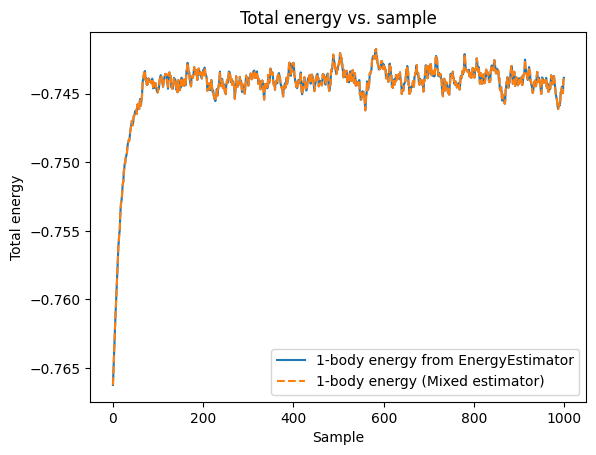

In [ ]:
%autoreload
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

from afqmctools.hamiltonian.converter import read_hamiltonian
from afqmctools.analysis.extraction import extract_observable,get_metadata
from afqmctools.analysis.transform import hermitize_factory,eval_one_body_obs_factory,eval_two_body_obs_factory

from afqmctools.analysis.average import WALKER_TYPE

# read the Hamiltonian
H = read_hamiltonian(scratch_dir / "hamil.h5")
M = H["nmo"]
Econst = H["enuc"]
hcore_k = H["hcore"]
hcore = hcore_k[0]

walker_type = WALKER_TYPE[get_metadata(scratch_dir/"qmc.s001.stat.h5")["WalkerType"]]

print(walker_type)

# set up a transform to compute the one-body energy from the one-rdm
eval_one_body_energy = eval_one_body_obs_factory(
    one_body_operator=hcore,
    walker_type=walker_type
)
# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)


# Extract and Transform data
Energy_1body = extract_observable(
    scratch_dir/"qmc.s001.stat.h5",    # filename
    estimator='mixed',
    name="one_rdm",                    # observable type
    ix=0,                              # index of the "average" - we'll return to this below!
    transform=[hermitize,eval_one_body_energy],  # list of transforms to apply *FROM LEFT TO RIGHT*
)
# add in constant energy for consistency with AuxilaryFields convention
Energy_1body += Econst


plt.plot(one_body_energy,label="1-body energy from EnergyEstimator")
plt.plot(Energy_1body,'--',label="1-body energy (Mixed estimator)")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Total energy")
plt.title("Total energy vs. sample")
plt.show()

(1000, 1)
(1000,)


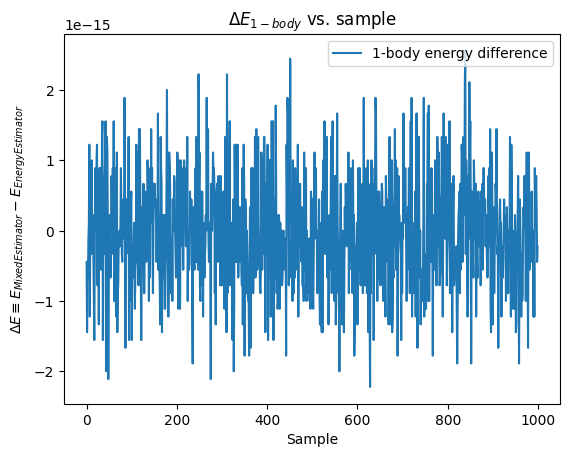

In [ ]:
# now, look at the difference!
delta_E = Energy_1body[:,0] - one_body_energy

print(Energy_1body.shape)
print(one_body_energy.shape)

# plot the difference between the two energies
plt.plot(delta_E,label="1-body energy difference")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"$\Delta E_{1-body}$ vs. sample")

plt.show()

As we can see, the energy computed using the one-body reduced density matrix with a mixed estimator yeilds the exact same one-body energies as the energy estimator to very high precision.
This is no surprise since the energy estimator is simply a specialized mixed estimator.


### Your Turn : Extract the 2rdm and compute the 2-body energy
---

Repeat the same excercise for the two-body energy.
As we saw in the energy estimator section, the exchange and direct coulomb energies are printed to file separately by the energy estimator.

To compute the two-body energy, you will need to measure the "diag_twordm" observable during AFQMC, and extract and transform it.

We provide code for setting up the appropriate transform functions in the code block below.

Note that the diagonal 2-rdm is stored as the upper-triangular of the full matrix.

129


/mnt/home/beskridge/software/SAFIRE/utils/afqmctools/analysis/transform.py:294: NumbaWarning: Cannot cache compiled function "transform" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  @jit(cache=True)
/mnt/home/beskridge/software/SAFIRE/build/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/beskridge/software/SAFIRE/build/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


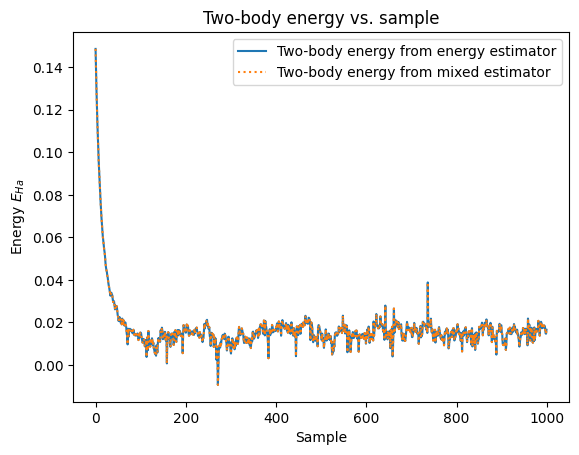

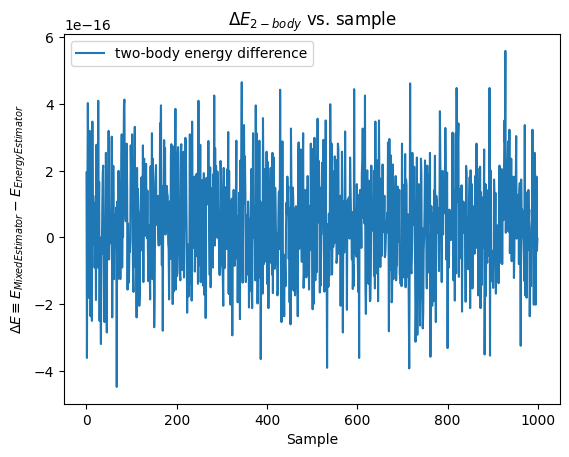

In [ ]:
%autoreload
import numpy as np
import matplotlib.pyplot as plt

from afqmctools.analysis.transform import hermitize_factory,eval_one_body_obs_factory,eval_two_body_obs_factory

ncv_k = H["nchol_pk"]
k_idk = 0 # gamma only for this tutorial
ncv = ncv_k[k]
print(ncv)

# taking the k=0 Cholesky vectors!
#cholesky_vectors = np.transpose(H["chol"][k].reshape((M,M,ncv)),(2,0,1))

cholesky_vectors = np.transpose(H["chol"][k].reshape((M,M,ncv)),(2,0,1))
cholesky_vectors_dagger = np.transpose(H["chol"][k].reshape((M,M,ncv)),(2,1,0)).conj()
eri = np.einsum("gil,gjk->iljk",cholesky_vectors,cholesky_vectors_dagger).flatten()

eval_two_body_energy = eval_two_body_obs_factory(
    two_body_operator=eri,
    walker_type=walker_type
)

Energy_2body_mixed = extract_observable(
    scratch_dir/"qmc.s001.stat.h5",
    estimator='mixed',
    name="two_rdm",
    ix=0,
    transform=eval_two_body_energy, # YOUR TURN: Supply the transform function to compute the two-body energy,
    batch_size=1
)

plt.plot(two_body_energy,label="Two-body energy from energy estimator")
plt.plot(Energy_2body_mixed,":",label="Two-body energy from mixed estimator")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"Energy $E_{Ha}$")
plt.title("Two-body energy vs. sample")
plt.show()


# plot the difference as well!
delta_E = Energy_2body_mixed[:,0] - two_body_energy

# plot the difference between the two energies
plt.plot(delta_E,label="two-body energy difference")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"$\Delta E_{2-body}$ vs. sample")

plt.show()


Once again, we see that the two body energy computed from the two-body reduced density matrix samples is the same as the two body energy from the energy estimator (after adding the exchange and direct Coulomb contributions together, of course).

## Averaging Observables
---

Averaging observables computed using AFQMC requires some care.

First, one must make sure that the data is equilibrated.

Second, in AFQMC, successive samples are not independent since they depend on the recent history of each walker.
This is known as "autocorrelation".
Care must be take to remove autocorrelation effects or the stochastic uncertainty will be underestimated.

The former can be achieved by visualizing the observable over imaginary time, and finding the equilibration time by inspection.
We saw this in the [Hello SAFIRE](https://colab.research.google.com/drive/1112A9uavLLuzUYKMss8n-FSDyAn7uXvV) tutorial.
afqmctools provides tools for automatically computing the auto-correlation time - i.e. the time interval at which measurments are no longer autocorrelated - and adjusting the number of effective samples accordingly.

In the code cell below, we demonstrate how to use the provided tools to automatically compute averages.

Average energy from average_observable() and transforms: [-0.72879696-8.43563225e-05j] +/- [0.0010608]


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/04_observables_solids/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy    -0.729271 +/-   0.000532 19.94  5.0/100.0


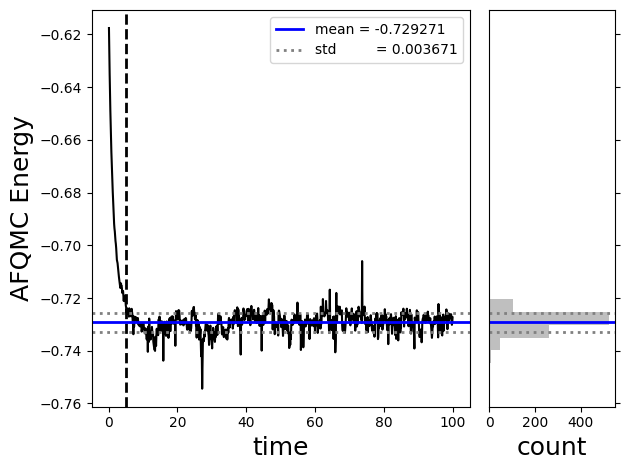

In [ ]:
# TODO here: demonstrate how to automatically average observables!
from afqmctools.analysis.average import average_observable

E1body, dE1body = average_observable(
    filename=scratch_dir/"qmc.s001.stat.h5",
    name = "one_rdm",
    eqlb=20, # EXERCISE: Set this to an appropriate value based on the energy vs projection time curve above.
    estimator='mixed',
    ix=0,
    blocksize=1,
    transform=[hermitize,eval_one_body_energy],
    remove_auto_correlation=True # you can turn this off if you prefer to remove autocorrelation yourself.
)

E2body, dE2body = average_observable(
    filename=scratch_dir/"qmc.s001.stat.h5",
    name = "two_rdm",
    eqlb=20, # EXERCISE: Set this to an appropriate value based on the energy vs projection time curve
    estimator='mixed',
    ix=0,
    blocksize=1,
    transform=eval_two_body_energy,
    remove_auto_correlation=True
)

print(f"Average energy from average_observable() and transforms: {E1body + E2body + Econst} +/- {np.sqrt(dE1body**2 + dE2body**2)}")

## compare with the analyze_scalar_stats result:

from stats.scalar_dat import analyze_scalar_data

_ = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    series_column = "time",
    nequil = 5,
    trace = True
))

## Back-Propagation (BP) in SAFIRE
----------------------------------

Mixed estimators are biased for observables $\hat{O}$ such that $[\hat{O},\hat{H}] \neq 0$, which requires the use of pure estimators. The Back-Propagation (BP) algorithm is used to compute pure estimators efficiently in SAFIRE.

### Basic BP Configuration
--------------------------

BP is invoked in SAFIRE by including a "back_propagation" estimator in the input file:

```json
{
  "estimator": {
    "name": "back_propagation",
    "path_restoration": true,
    "bp_walker_ortho_interval": 5,
    "measure_interval_multiplier": 20,
    "equil_multiplier": 100,
    "onerdm": {
      "name": "one_rdm"
    }
  }
}
```

Observables are added to the BP block in the same way as for mixed estimators.

### Measurement Intervals
-------------------------

Since BP involves an additional projection, the measurement interval controls the number of back-propagated steps.
Just as in the execute block or a mixed estimator block, the input file includes a measurement interval "multiplier", and the actual measurement interval, $m$, is determined as:

$$
m = (\textrm{measure_interval_multiplier}) \times (\textrm{population_control_interval})
$$

### Multiple BP Lengths
---

SAFIRE implements the capability of running BP with multiple BP measurement lengths.
We call each measurement with a different BP length an "average".
This allows the forward projection to be reused while checking for convergence in the BP length.
To define multiple BP lengths/averages, simply provide a JSON array for measure_interval_multiplier corresponding to all of the BP lengths that you would like to use:

```json
{
  "estimator": {
    "name": "back_propagation",
    "path_restoration": true,
    "bp_walker_ortho_interval": 10,
    "measure_interval_multiplier": [60, 70, 80],
    "equil_multiplier": 80,
    "onerdm": {
      "name": "one_rdm"
    }
  }
}
```

### Equilibration Phase
---

The BP estimator implements an equilibration phase at the beginning of the AFQMC calculation where no BP is performed.
This is recommended since computing observables is expensive and since AFQMC needs to equilibrate before samples can meaningfully contribute to the average.
Similarly to the measure_interval_multiplier, the equilibration time is specified as an equilibration multiplier (`"equil_multiplier"`) and the actual equilibration time is given by:

$$\text{equil_time} = (\text{equil_multiplier}) \times (\text{population_control_interval})$$


### All Settings
----------------

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        measure_interval_multiplier</b></font> |  <font size="4"> 1 </font> | <font size="4"> controls the number of back propagation steps which are determined as $$(\text{number of BP steps}) = (\text{measure_interval_multiplier}) \times (\text{population_control_interval})$$. Can be either a single value or multiple values. If multiple values are provided, BP will be performed with each corresponding number of BP steps and observables are accumulated and saved for each distinct BP length. </font> |
| <font size="4"><b> equil_multiplier </b></font> | <font size="4">0</font> |  <font size="4">The multiplier that determines the length of the equilibration phase. The equilibration phase length is computed as $(equilibration\_length) = (equil\_multiplier) * (population\_control\_inveral)$ where the population control interval is defined in the execute block. During the equilibration phase, observables are not computed. </font>|
| <font size="4"><b>        bp_walker_ortho_interval</b></font> |  <font size="4"> 1 </font> | <font size="4">  interval for performing walker orthonormalization during back-propagation (i.e. for the left-hand side Walkers) </font> |
| <font size="4"><b>        path_restoration</b></font> |  <font size="4"> false </font> | <font size="4"> If true, perform path restoration. </font> |
| <font size="4"><b>        extra_path_restoration</b></font> |  <font size="4"> false </font> | <font size="4">  If true, perform an extra path restoration. </font> |


### Demonstraiton of BP
-----------------------

For the sake of execution time, we will compute only the one-rdm using the back-propagation estimator.
We will find that the one-body energy computed using the BP one-rdm will *not* agree with the one computed using a mixed estimator.
The BP-estimated one-body energy is unbiased, and represents a better estimate of the one-body energy than that provided by the mixed estimator.

In [ ]:
# Example: Setting up a BP calculation with multiple BP lengths
from afqmctools.inputs.from_hdf import write_json

# Set up AFQMC parameters with back-propagation
execute_options_bp = {
    "walker_set": {
        "walker_type": "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "measure_interval_multiplier": 1,
    "population_control_interval": 10,
    "walker_ortho_interval": 10,
    "n_walkers_per_mpi_task": 200,
    "seed": 42,
    "estimator": {
        "name": "back_propagation",
        "path_restoration": True,
        "bp_walker_ortho_interval": 10,
        "measure_interval_multiplier": [4,5,6],  # Multiple BP lengths
        "equil_multiplier": 0,  # Equilibration phase
        "onerdm": {
            "name": "one_rdm"
        }
    }
}

write_json(
    scratch_dir / "afqmc_bp.json",
    fwfn0=scratch_dir / "wfn.h5",
    fham0=scratch_dir / "hamil.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options_bp,
    series=2
)

print("Back-propagation input file created with the following BP parameters:")
print(f"- Multiple BP lengths: {execute_options_bp['estimator']['measure_interval_multiplier']}")
print(f"- Equilibration multiplier: {execute_options_bp['estimator']['equil_multiplier']}")
print(f"- Population control interval: {execute_options_bp['population_control_interval']}")
print(f"- Actual BP lengths: {[m * execute_options_bp['population_control_interval'] for m in execute_options_bp['estimator']['measure_interval_multiplier']]}")
print(f"- Equilibration time: {execute_options_bp['estimator']['equil_multiplier'] * execute_options_bp['population_control_interval']}")

Back-propagation input file created with the following BP parameters:
- Multiple BP lengths: [4, 5, 6]
- Equilibration multiplier: 0
- Population control interval: 10
- Actual BP lengths: [40, 50, 60]
- Equilibration time: 0


In [ ]:
# Run AFQMC with back-propagation
print("Running AFQMC with back-propagation estimator...")
print("This will take longer than mixed estimators due to the additional back-propagation steps.")

run_afqmc(
    run_dir=scratch_dir,
    input_file="afqmc_bp.json",
    np=16,
    output_file=None
)

Running AFQMC with back-propagation estimator...
This will take longer than mixed estimators due to the additional back-propagation steps.
Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 9c503defb1cb7612b100318b4394dce7c4b1fda1
app git commit date: Mon Dec 1 11:33:42 2025 -0500
 AFQMCFactory Project setti

360.5198784219101

In [ ]:
# Extract and analyze BP results
from afqmctools.analysis.extraction import extract_observable, get_metadata
from afqmctools.analysis.average import WALKER_TYPE
from afqmctools.analysis.transform import hermitize_factory

# Check the metadata to understand the walker type
metadata = get_metadata(scratch_dir / "qmc.s002.stat.h5")
bp_metadata = get_metadata(scratch_dir / "qmc.s002.stat.h5", path="/Observables/BackPropagated/")

walker_type = WALKER_TYPE[metadata["WalkerType"]]
print(f"Walker type: {walker_type}")

# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)

bp_lengths = bp_metadata["BackPropSteps"]
naverages = len(bp_lengths)
bp_energy = np.zeros((naverages),dtype=np.complex128)
bp_energy_err = np.zeros((naverages),dtype=np.complex128)

for iav, bp_length in enumerate(bp_lengths):
    print(f"Extracting average {iav} (BP length = {bp_length} steps)")

    # Extract the one-RDM for this average
    energy_bp, denergy_bp = average_observable(
        scratch_dir / "qmc.s002.stat.h5",
        estimator='back_propagated',
        name="one_rdm",
        eqlb=20,
        ix=iav,  # Index of the BP average
        transform=[hermitize,eval_one_body_energy],  # Apply hermitization
        batch_size=10
    )
    bp_energy[iav] = energy_bp[0] + Econst
    bp_energy_err[iav] = denergy_bp[0]


Walker type: collinear
Extracting average 0 (BP length = 40 steps)
Extracting average 1 (BP length = 50 steps)
Extracting average 2 (BP length = 60 steps)




====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/04_observables_solids/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = OneBodyEnergyEstim__nume_real
[+] reblock          = 1               
[+] list             = False           
[+] trace            = False           
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

OneBodyEnergyEstim__nume_real  -0.743961 +/-   0.000085 14.29 10.0/100.0


/mnt/home/beskridge/software/SAFIRE/build/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/beskridge/software/SAFIRE/build/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/mnt/home/beskridge/software/SAFIRE/build/safire/lib/python3.11/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


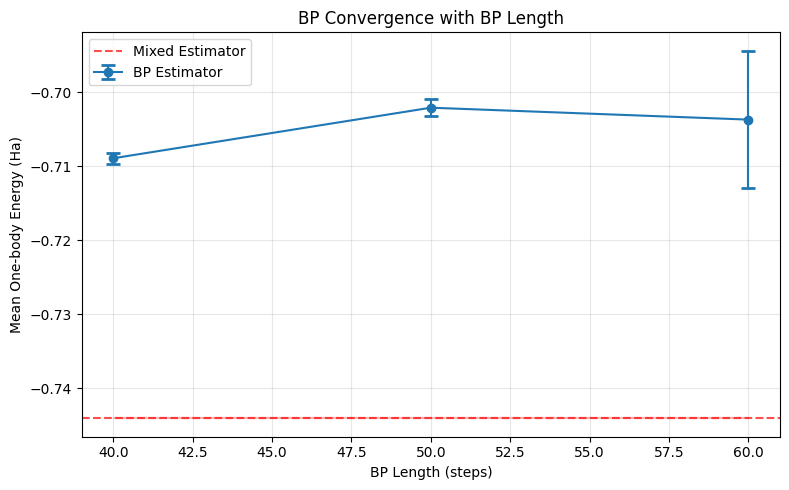

In [ ]:
import matplotlib.pyplot as plt
from stats.scalar_dat import analyze_scalar_data

E_mixed, dE_mixed = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    series_column = "time",
    column = "OneBodyEnergyEstim__nume_real",
    nequil = 10
))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# plot reference value from mixed
ax.fill_between([min(bp_lengths), max(bp_lengths)],
                 E_mixed - dE_mixed, E_mixed + dE_mixed,
                 alpha=0.2, color='red')
ax.axhline(y=E_mixed, color='red', linestyle='--', alpha=0.7, label=f'Mixed Estimator')

# Plot convergence
ax.errorbar(bp_lengths, bp_energy, yerr=bp_energy_err, marker='o', capsize=5, capthick=2, label='BP Estimator')

ax.set_xlabel('BP Length (steps)')
ax.set_ylabel('Mean One-body Energy (Ha)')
ax.set_title('BP Convergence with BP Length')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Key Takeaways from Back-Propagation Analysis
---

**When to Use BP vs Mixed Estimators:**

1. **Mixed Estimators**: Use for observables that commute with the Hamiltonian (like energy). They are computationally cheaper and provide unbiased estimates.

2. **Back-Propagation**: Required for observables that do not commute with the Hamiltonian (like the one-body reduced density matrix). BP provides pure estimators that are unbiased.

**Important BP Configuration Points:**

- **Equilibration**: Always include an equilibration phase (`equil_multiplier`) to allow AFQMC to reach equilibrium before BP measurements begin.

- **Multiple BP Lengths**: Use multiple BP lengths to check convergence. Longer BP lengths generally provide more accurate results but are more expensive.

- **Computational Cost**: BP calculations are significantly more expensive than mixed estimators due to the additional back-propagation steps.

**Convergence Analysis:**

The plots above show how the BP estimator converges with increasing BP length. For observables that don't commute with the Hamiltonian, you should see:
- Different results between mixed and BP estimators (showing the bias in mixed estimators)
- Convergence of BP results as the BP length increases
- Eventually, BP results should converge to the true value

This demonstrates why BP is essential for computing unbiased estimates of observables like charge densities, spin densities, and other quantities derived from the one-body reduced density matrix.

&nbsp;

&nbsp;

## Summary
---

<font size="4">
In this tutorial, you were acquainted with how to compute general observables with SAFIRE.
</font>

&nbsp;

## What you learned
---

<font size="4">

1. What a mixed estimator is and when to use one to compute an observable
2. What a back-propagated estimator is and when to use one to compute an observable
3. How to compute observables in post-processing with afqmctools
</font>

&nbsp;